In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModel, BertTokenizerFast
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import transformers



In [3]:
import pandas as pd

# loading datasets
true_data = pd.read_csv(r'C:\new_fake_project_from_0\a1_True.csv')
fake_data = pd.read_csv(r'C:\new_fake_project_from_0\a2_Fake.csv')

# preview
true_data.head()

# add labels
true_data['Target'] = 'True'
fake_data['Target'] = 'Fake'

# merge + shuffle
data = pd.concat([true_data, fake_data]).sample(frac=1).reset_index(drop=True)

# inspect
print(data.shape)
data.head()


(44898, 5)


,title,text,subject,date,Target
0,Merkel points to grand coalition with Social D...,BERLIN (Reuters) - Chancellor Angela Merkel on...,worldnews,"November 25, 2017",True
1,CONFUSED.GOV: Obama’s Imperial Mideast Policy ...,21st Century Wire says We just learned this we...,Middle-east,"August 30, 2016",Fake
2,TED CRUZ: Vilification of Law Enforcement Comi...,Ferguson was the a launching pad for Obama s w...,left-news,"Sep 1, 2015",Fake
3,U.S. says Turkish gold trader facing Iran tria...,NEW YORK (Reuters) - A wealthy Turkish gold tr...,worldnews,"November 3, 2017",True
4,China state media says U.S. trade probe will h...,SHANGHAI (Reuters) - A decision by the United ...,politicsNews,"August 15, 2017",True


In [4]:
# Target column is made of string values True/Fake, let's change it to numbers 0/1 (Fake=1)
data['label'] = pd.get_dummies(data.Target)['Fake']

In [5]:
data.head()

,title,text,subject,date,Target,label
0,Merkel points to grand coalition with Social D...,BERLIN (Reuters) - Chancellor Angela Merkel on...,worldnews,"November 25, 2017",True,False
1,CONFUSED.GOV: Obama’s Imperial Mideast Policy ...,21st Century Wire says We just learned this we...,Middle-east,"August 30, 2016",Fake,True
2,TED CRUZ: Vilification of Law Enforcement Comi...,Ferguson was the a launching pad for Obama s w...,left-news,"Sep 1, 2015",Fake,True
3,U.S. says Turkish gold trader facing Iran tria...,NEW YORK (Reuters) - A wealthy Turkish gold tr...,worldnews,"November 3, 2017",True,False
4,China state media says U.S. trade probe will h...,SHANGHAI (Reuters) - A decision by the United ...,politicsNews,"August 15, 2017",True,False


([<matplotlib.patches.Wedge at 0x252beed1010>,
 [Text(-1.1968726922452788, -0.0865780489358482, 'Fake'),
  Text(1.196872705318187, 0.08657786821309862, 'True')],
 [Text(-0.6981757371430793, -0.05050386187924477, '52.3%'),
  Text(0.6981757447689423, 0.05050375645764086, '47.7%')])

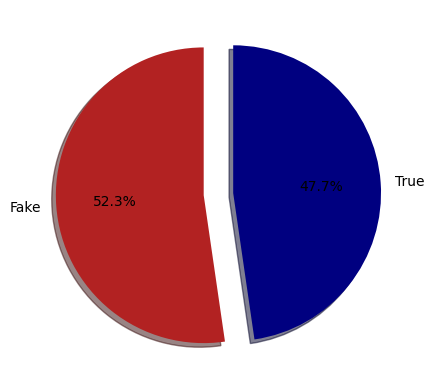

In [6]:
# Checking if our data is well balanced
label_size = [data['label'].sum(),len(data['label'])-data['label'].sum()]
plt.pie(label_size,explode=[0.1,0.1],colors=['firebrick','navy'],startangle=90,shadow=True,labels=['Fake','True'],autopct='%1.1f%%')

In [7]:
# Train-Validation-Test set split into 70:15:15 ratio
# Train-Temp split
train_text, temp_text, train_labels, temp_labels = train_test_split(data['title'], data['label'],
                                                                    random_state=2018,
                                                                    test_size=0.3,
                                                                    stratify=data['Target'])
# Validation-Test split
val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels,
                                                                random_state=2018,
                                                                test_size=0.5,
                                                                stratify=temp_labels)

BERT fine-tuning

In [8]:
import torch
print("Torch OK:", torch.__version__)

from transformers import is_torch_available
print("Torch detected by transformers:", is_torch_available())

Torch OK: 2.10.0+cpu
Torch detected by transformers: True


In [9]:
import sys, torch, transformers
print(sys.executable)
print(torch.__file__)
print(transformers.__file__)

c:\new_fake_project_from_0\myenv\Scripts\python.exe
c:\new_fake_project_from_0\myenv\Lib\site-packages\torch\__init__.py
c:\new_fake_project_from_0\myenv\Lib\site-packages\transformers\__init__.py


In [10]:
# Load BERT model and tokenizer via HuggingFace Transformers
bert = AutoModel.from_pretrained('bert-base-uncased')
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Preparing input data

Text(0, 0.5, 'Number of texts')

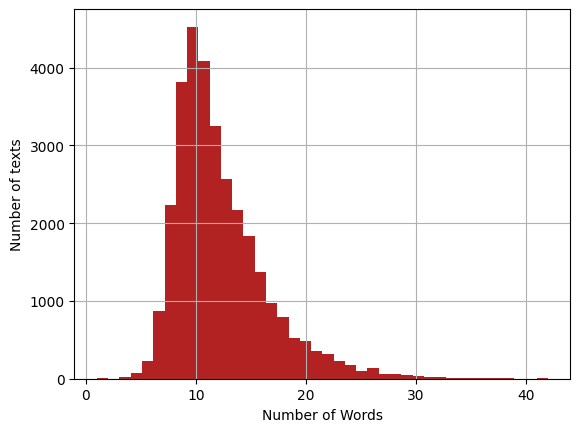

In [11]:
# Plot histogram of the number of words in train data 'title'
seq_len = [len(title.split()) for title in train_text]

pd.Series(seq_len).hist(bins = 40,color='firebrick')
plt.xlabel('Number of Words')
plt.ylabel('Number of texts')

In [13]:
sample_data = [
    "Build fake news model.",
    "Using bert."
]

tokenized_sample_data = tokenizer(
    sample_data,
    padding=True,
    truncation=True,
    return_tensors="pt"   # optional (for PyTorch)
)

print(tokenized_sample_data)

{'input_ids': tensor([[  101,  3857,  8275,  2739,  2944,  1012,   102],
        [  101,  2478, 14324,  1012,   102,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0, 0]])}


In [14]:
MAX_LENGTH = 15

# Train
tokens_train = tokenizer(
    train_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

# Validation
tokens_val = tokenizer(
    val_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

# Test
tokens_test = tokenizer(
    test_text.tolist(),
    max_length=MAX_LENGTH,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

In [25]:
# Clean and convert labels safely

train_y = torch.tensor(
    train_labels.astype(str).str.strip().str.lower()
    .map({'true':1, 'fake':0})
    .fillna(0)   # replace any unknown values with 0
    .astype(int)
    .values,
    dtype=torch.long
)

val_y = torch.tensor(
    val_labels.astype(str).str.strip().str.lower()
    .map({'true':1, 'fake':0})
    .fillna(0)
    .astype(int)
    .values,
    dtype=torch.long
)

test_y = torch.tensor(
    test_labels.astype(str).str.strip().str.lower()
    .map({'true':1, 'fake':0})
    .fillna(0)
    .astype(int)
    .values,
    dtype=torch.long
)

In [26]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch

# batch size
batch_size = 32

# (optional but recommended) device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- TRAIN SET --------
train_data = TensorDataset(train_seq, train_mask, train_y)

train_sampler = RandomSampler(train_data)

train_dataloader = DataLoader(
    train_data,
    sampler=train_sampler,
    batch_size=batch_size
)

# -------- VALIDATION SET --------
val_data = TensorDataset(val_seq, val_mask, val_y)

val_sampler = SequentialSampler(val_data)

val_dataloader = DataLoader(
    val_data,
    sampler=val_sampler,
    batch_size=batch_size
)

# -------- TEST SET (you missed DataLoader here earlier) --------
test_data = TensorDataset(test_seq, test_mask, test_y)

test_sampler = SequentialSampler(test_data)

test_dataloader = DataLoader(
    test_data,
    sampler=test_sampler,
    batch_size=batch_size
)

print("Train batches:", len(train_dataloader))
print("Validation batches:", len(val_dataloader))
print("Test batches:", len(test_dataloader))

Train batches: 983
Validation batches: 211
Test batches: 211


Freeze Layers

In [27]:
# Freezing the parameters and defining trainable BERT structure
for param in bert.parameters():
    param.requires_grad = False    # false here means gradient need not be computed

Defining Model Architecture

In [28]:

from torch.optim import AdamW   # ✅ correct modern import
from transformers import AutoModel

# Load pretrained BERT
bert = AutoModel.from_pretrained('bert-base-uncased')

# Define model
class BERT_Arch(nn.Module):
    def __init__(self, bert):
        super(BERT_Arch, self).__init__()

        self.bert = bert
        
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, sent_id, mask):
        # BERT output
        outputs = self.bert(input_ids=sent_id, attention_mask=mask)
        cls_hs = outputs.pooler_output   # CLS token output

        # Classification head
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x   # raw logits

# Initialize model
model = BERT_Arch(bert)

# Device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Optimizer
optimizer = AdamW(model.parameters(), lr=1e-5)

# Loss function
loss_fn = nn.CrossEntropyLoss()

# Epochs
epochs = 2

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Defining train and Evaluation function

In [29]:
def train():
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_dataloader):

        if step % 50 == 0 and step != 0:
            print(f'  Batch {step} of {len(train_dataloader)}')

        # ✅ Move batch to device (IMPORTANT)
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # ✅ clear gradients
        optimizer.zero_grad()

        # forward pass
        preds = model(sent_id, mask)

        # compute loss
        loss = loss_fn(preds, labels)

        # accumulate loss
        total_loss += loss.item()

        # backward pass
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update weights
        optimizer.step()

    avg_loss = total_loss / len(train_dataloader)
    return avg_loss




def evaluate():
    print("\nEvaluating...")
    model.eval()

    total_loss = 0

    for step, batch in enumerate(val_dataloader):

        if step % 50 == 0 and step != 0:
            print(f'  Batch {step} of {len(val_dataloader)}')

        # ✅ move to device
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # no gradient calculation
        with torch.no_grad():
            preds = model(sent_id, mask)

            loss = loss_fn(preds, labels)
            total_loss += loss.item()

    avg_loss = total_loss / len(val_dataloader)
    return avg_loss

In [30]:
# Train and validate

best_valid_loss = float('inf')

train_losses = []
valid_losses = []

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1} / {epochs}')

    # train
    train_loss = train()

    # evaluate
    valid_loss = evaluate()

    # save best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print("✅ Model saved!")

    # store losses
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'Training Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')


Epoch 1 / 2
  Batch 50 of 983
  Batch 100 of 983
  Batch 150 of 983
  Batch 200 of 983
  Batch 250 of 983
  Batch 300 of 983
  Batch 350 of 983
  Batch 400 of 983
  Batch 450 of 983
  Batch 500 of 983
  Batch 550 of 983
  Batch 600 of 983
  Batch 650 of 983
  Batch 700 of 983
  Batch 750 of 983
  Batch 800 of 983
  Batch 850 of 983
  Batch 900 of 983
  Batch 950 of 983

Evaluating...
  Batch 50 of 211
  Batch 100 of 211
  Batch 150 of 211
  Batch 200 of 211
✅ Model saved!
Training Loss: 0.156
Validation Loss: 0.075

Epoch 2 / 2
  Batch 50 of 983
  Batch 100 of 983
  Batch 150 of 983
  Batch 200 of 983
  Batch 250 of 983
  Batch 300 of 983
  Batch 350 of 983
  Batch 400 of 983
  Batch 450 of 983
  Batch 500 of 983
  Batch 550 of 983
  Batch 600 of 983
  Batch 650 of 983
  Batch 700 of 983
  Batch 750 of 983
  Batch 800 of 983
  Batch 850 of 983
  Batch 900 of 983
  Batch 950 of 983

Evaluating...
  Batch 50 of 211
  Batch 100 of 211
  Batch 150 of 211
  Batch 200 of 211
✅ Model saved!


Model Performance

In [36]:
torch.save(model.state_dict(), 'best_model.pt')

In [37]:
# load weights of best model
path = 'C:\\new_fake_project_from_0\\best_model.pt'
model.load_state_dict(torch.load(path))

<All keys matched successfully>

In [39]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()

all_preds = []

with torch.no_grad():
    for batch in test_dataloader:
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        outputs = model(sent_id, mask)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())

# Convert true labels
y_true = test_y.cpu().numpy()

print(classification_report(y_true, all_preds))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      3212
           1       0.91      0.85      0.88      3523

    accuracy                           0.88      6735
   macro avg       0.88      0.88      0.88      6735
weighted avg       0.88      0.88      0.88      6735



Fake news prediction

In [42]:
# testing on unseen data
text = ["Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing",     # Fake
                    "WATCH: George W. Bush Calls Out Trump For Supporting White Supremacy",               # Fake
                    "U.S. lawmakers question businessman at 2016 Trump Tower meeting: sources",           # True
                    "Trump administration issues new rules on U.S. visa waivers"                          # True
                    ]

# tokenize and encode sequences in the test set
MAX_LENGHT = 15
tokens_unseen = tokenizer(
    text,
    max_length=15,
    padding='max_length',
    truncation=True
)

unseen_seq = torch.tensor(tokens_unseen['input_ids'])
unseen_mask = torch.tensor(tokens_unseen['attention_mask'])

with torch.no_grad():
  preds = model(unseen_seq, unseen_mask)
  preds = preds.detach().cpu().numpy()

preds = np.argmax(preds, axis = 1)
preds

array([1, 1, 0, 0])